# Proyecto Final Data Science III

**Autor:** Lucas Scalise  
**Comisión:** 86780  


---

#Objetivo general

Desarrollar un sistema capaz de clasificar automáticamente reseñas cinematográficas en sentimientos positivos o negativos mediante técnicas de procesamiento de lenguaje natural y modelos de machine learning y deep learning.

# Abstracto

El crecimiento de las plataformas digitales ha generado un volumen cada vez mayor de contenido textual producido por los usuarios. En sitios especializados en cine, miles de personas publican diariamente reseñas expresando sus opiniones sobre películas, lo que representa una fuente valiosa de información para comprender la percepción del público.

El objetivo de este proyecto es desarrollar un sistema capaz de analizar automáticamente el sentimiento de una reseña cinematográfica utilizando técnicas de procesamiento de lenguaje natural (NLP) y modelos de machine learning y deep learning.

Para ello se empleará el dataset **IMDb Dataset of 50K Movie Reviews**, compuesto por 50.000 reseñas reales clasificadas como positivas o negativas. A lo largo del proyecto se realizará una exploración de los datos, un proceso completo de limpieza y normalización del texto, un análisis lingüístico mediante frecuencias y n-gramas, la transformación del texto utilizando TF-IDF y la construcción de distintos modelos de clasificación. A partir de esta representación se construirán modelos de machine learning y una red neuronal  para predecir el sentimiento de nuevas reseñas.

# Motivación

Actualmente, una gran parte de las decisiones de compra y consumo se encuentran influenciadas por las opiniones publicadas por otros usuarios en Internet. Plataformas como IMDb reciben miles de reseñas sobre películas, las cuales contienen información útil acerca de la satisfacción, preferencias y experiencias del público.

Sin embargo, el análisis manual de esta cantidad de información resulta poco práctico y requiere una inversión considerable de tiempo y recursos. En este contexto, el procesamiento de lenguaje natural ofrece herramientas que permiten automatizar el análisis de grandes volúmenes de texto y extraer conocimiento de manera eficiente.

Este proyecto busca aplicar dichas técnicas para construir un sistema capaz de identificar automáticamente el sentimiento expresado en una reseña cinematográfica, facilitando el análisis masivo de opiniones.

# Audiencia

Los resultados obtenidos en este proyecto pueden resultar de interés para:

- Plataformas de streaming y sitios especializados en cine, que pueden utilizar estos modelos para resumir rápidamente la opinión general de los usuarios.

- Empresas dedicadas al entretenimiento, interesadas en conocer la recepción de sus producciones.

- Analistas de datos y científicos de datos que trabajen con información textual.

- Investigadores y estudiantes que deseen introducirse en el procesamiento de lenguaje natural y la clasificación automática de texto.


# Preguntas de análisis

- ¿Cómo se distribuyen las reseñas positivas y negativas dentro del dataset?

- ¿Qué diferencias existen entre el vocabulario utilizado en ambos sentimientos?

- ¿Qué impacto tiene el preprocesamiento del texto sobre la representación de las reseñas?

- ¿Qué palabras y expresiones aparecen con mayor frecuencia en cada categoría?

- ¿Qué modelo de clasificación obtiene el mejor rendimiento?

- ¿La incorporación de una red neuronal mejora los resultados obtenidos mediante modelos tradicionales de Machine Learning?

# Hipótesis

- El contenido textual de las reseñas contiene suficiente información para identificar correctamente el sentimiento expresado por los usuarios.

- La aplicación de técnicas de preprocesamiento, como la eliminación de ruido, la tokenización, la eliminación de stopwords y la lematización, mejorará la representación del texto y favorecerá el desempeño de los modelos de clasificación.

- Las palabras y expresiones más frecuentes diferirán significativamente entre las reseñas positivas y las negativas, permitiendo identificar patrones lingüísticos característicos de cada sentimiento.

- Los modelos tradicionales de Machine Learning, como la Regresión Logística y Naive Bayes, alcanzarán un buen desempeño en la clasificación de sentimientos utilizando representaciones basadas en TF-IDF.

- Una red neuronal con una arquitectura más compleja obtendrá un rendimiento igual o superior al de los modelos tradicionales, aprovechando la mayor capacidad de aprendizaje proporcionada por el deep learning.

---

# 1. Configuración del entorno

In [107]:
!pip install wordcloud -q

# 2. Importación de librerías

In [108]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

#NLP
import nltk
import re
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

#Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#Deep learning
import tensorflow as tf

#Utilidades
import warnings
import re
from collections import Counter

# 3. Configuración general

Se establecen los parámetros generales que se utilizarán durante todo el proyecto, incluyendo la configuración de las visualizaciones, la reproducibilidad de los resultados y otras opciones que facilitan el análisis de los datos.

In [109]:
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

SEED = 42

np.random.seed(SEED)

tf.random.set_seed(SEED)

# 4. Descarga de recursos de NLTK

In [110]:
resources = [
    "punkt",
    "punkt_tab",
    "stopwords",
    "wordnet",
    "omw-1.4",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng"
]


for resource in resources:
    nltk.download(resource, quiet=True)

print("Todos los recursos de NLTK fueron descargados correctamente.")

Todos los recursos de NLTK fueron descargados correctamente.


# 5. Carga del dataset

In [111]:
import kagglehub
import os

path = kagglehub.dataset_download("rehanliaqat17/imbd-dataset")

dataset_path = os.path.join(
    path,
    "IMDB_Dataset.csv"
)

df = pd.read_csv(dataset_path)

print("Dataset cargado correctamente.")

Using Colab cache for faster access to the 'imbd-dataset' dataset.
Dataset cargado correctamente.


# 6. Lectura de datos

**Dimensiones**

In [112]:
print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

df.head()

Cantidad de filas: 50000
Cantidad de columnas: 2


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**Variables**

In [113]:
df.columns

pd.DataFrame({
    "Variable": df.columns,
    "Descripción": [
        "Texto completo de la reseña",
        "Sentimiento asociado a la reseña"
    ]
})

,Variable,Descripción
0,review,Texto completo de la reseña
1,sentiment,Sentimiento asociado a la reseña


**Información general**

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


**Distribución de clases**

In [115]:
class_distribution = pd.DataFrame({
    "Cantidad": df["sentiment"].value_counts(),
    "Porcentaje (%)": (
        df["sentiment"]
          .value_counts(normalize=True)
          .mul(100)
          .round(2)
    )
})

class_distribution

,Cantidad,Porcentaje (%)
sentiment,,
positive,25000,50.0
negative,25000,50.0


**Ejemplos de reseñas**

In [116]:
df.sample(
    5,
    random_state=SEED
)

,review,sentiment
33553,I really liked this Summerslam due to the look...,positive
9427,Not many television shows appeal to quite as m...,positive
199,The film quickly gets to a major chase scene w...,negative
12447,Jane Austen would definitely approve of this o...,positive
39489,Expectations were somewhat high for me when I ...,negative


**Interpretación**

La lectura de datos permitió observar que el dataset presenta una estructura sencilla, compuesta por dos variables: el texto de la reseña (review) y el sentimiento asociado (sentiment).

Además, se verificó la existencia o ausencia de valores faltantes.

Finalmente, se comprobó que los datos se encuentran balanceados, lo cual es fundamental para el entrenamiento de modelos de clasificación


# 7. Análisis Exploratorio de Datos

**Longitud de las reseñas**

Para ello, se crearán dos nuevas variables:

- review_length: cantidad de caracteres de cada reseña.
- word_count: cantidad de palabras presentes en cada reseña.

In [117]:
df["review_length"] = df["review"].str.len()
df["word_count"] = df["review"].str.split().str.len()

df.head()

,review,sentiment,review_length,word_count
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


**Estadísticas descriptivas**

Se analizan las principales medidas descriptivas de las nuevas variables creadas para conocer el comportamiento general de la longitud de las reseñas.

In [118]:
df[
    ["review_length", "word_count"]
].describe().round(2)

,review_length,word_count
count,50000.00,50000.00
mean,1309.43,231.16
std,989.73,171.34
min,32.00,4.00
25%,699.00,126.00
50%,970.00,173.00
75%,1590.25,280.00
max,13704.00,2470.00


**Distribución de sentimientos**

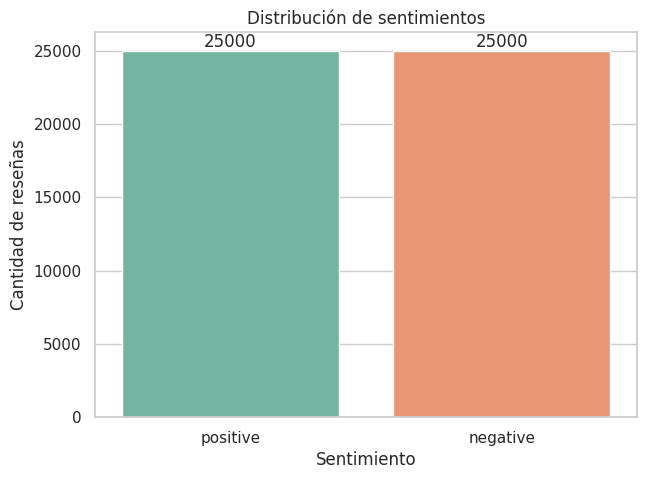

In [119]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="sentiment",
    palette="Set2"
)

plt.title("Distribución de sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reseñas")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Se puede apreciar que la distribución de las reseñas se encuentra balanceada

**Longitud de las reseñas**

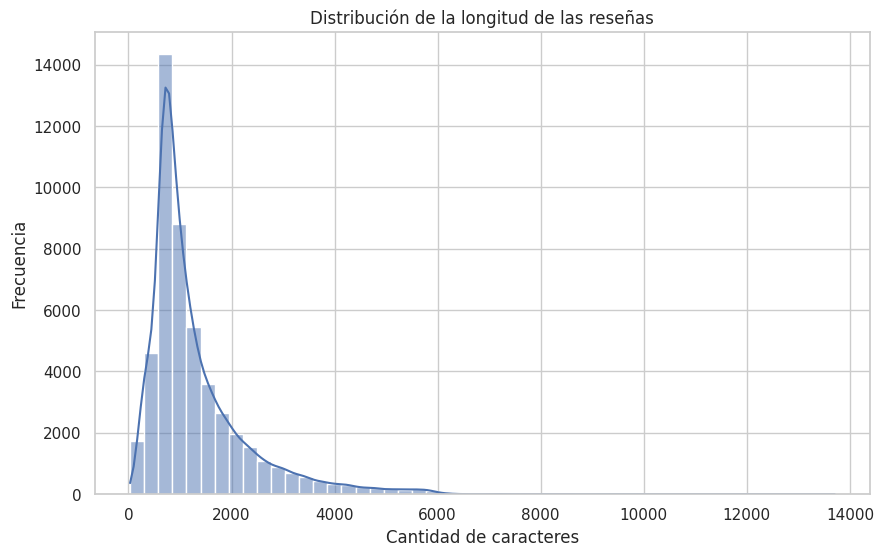

In [120]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="review_length",
    bins=50,
    kde=True
)

plt.title("Distribución de la longitud de las reseñas")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")

plt.show()

Se puede apreciar que entre 800 y 1100 caracteres por reseña es el predominante en aproximadamente 14000 reseñas.

**Cantidad de palabras por reseña**

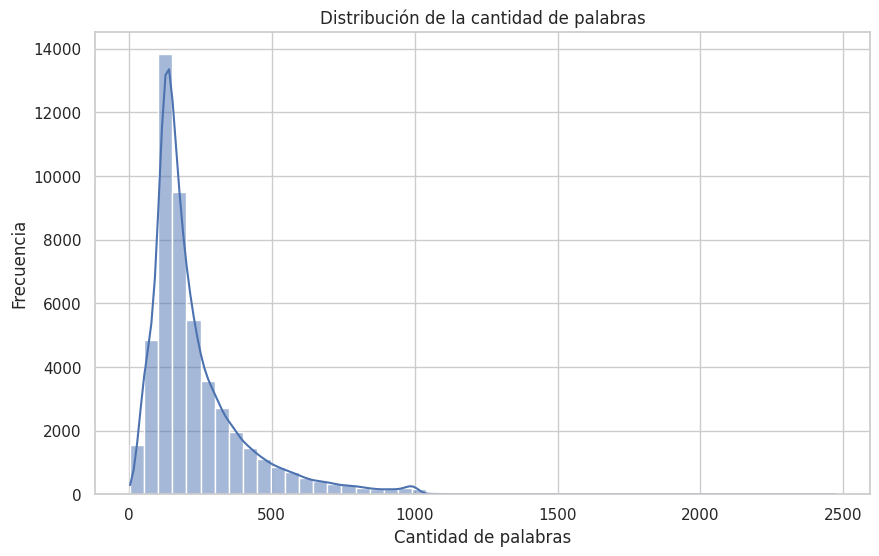

In [121]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="word_count",
    bins=50,
    kde=True
)

plt.title("Distribución de la cantidad de palabras")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")

plt.show()

Se puede apreciar que 150 palabras por reseña es el predominante en aproximadamente 14000 reseñas.

**Longitud de las reseñas según el sentimiento**

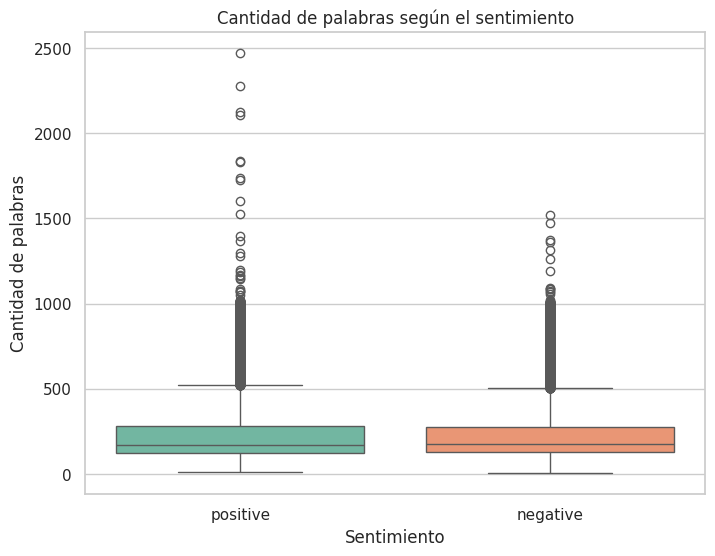

In [122]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="sentiment",
    y="word_count",
    palette="Set2"
)

plt.title("Cantidad de palabras según el sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de palabras")

plt.show()

Se aprecian similitudes en la cantidad de palabras según el sentimiento con una leve inclinación en el uso de más palabras cuando es positiva

**Estadísticas por sentimiento**

In [123]:
df.groupby("sentiment")["word_count"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,25000.0,229.46,164.95,4.0,128.0,174.0,278.0,1522.0
positive,25000.0,232.85,177.50,10.0,125.0,172.0,284.0,2470.0


**Reseñas con mayor longitud**

In [124]:
df[
    ["review", "sentiment", "word_count"]
].sort_values(
    by="word_count",
    ascending=False
).head(5)

,review,sentiment,word_count
31481,Match 1: Tag Team Table Match Bubba Ray and Sp...,positive,2470
40521,There's a sign on The Lost Highway that says:<...,positive,2278
31436,"Back in the mid/late 80s, an OAV anime by titl...",positive,2125
31240,"(Some spoilers included:)<br /><br />Although,...",positive,2108
12647,Titanic directed by James Cameron presents a f...,positive,1839


**Cantidad de reseñas que contienen HTML**

In [125]:
html_reviews = df["review"].str.contains("<br />", regex=False).sum()

print(f"Reseñas con etiquetas HTML: {html_reviews}")

Reseñas con etiquetas HTML: 29200


**Conclusiones del análisis exploratorio**

El análisis exploratorio permitió conocer las principales características del dataset

Se observó la distribución de las clases, la longitud de las reseñas y la cantidad de palabras presentes en cada texto. Además, se identificaron diferencias en la extensión de las opiniones y la existencia de reseñas considerablemente más largas que el promedio, las cuales se inclinaban más a ser positivas.

Por otra parte, el análisis de la calidad del texto evidenció la presencia de etiquetas HTML en una parte importante de las reseñas. Estos elementos no aportan información al análisis de sentimientos y deberán eliminarse durante el preprocesamiento.

# 8. Preprocesamiento de texto con NLP

**Creación de una copia del dataset**

In [126]:
df_clean = df.copy()

print(f"Registros antes del preprocesamiento: {len(df_clean)}")

Registros antes del preprocesamiento: 50000


**Preparación**



In [127]:
stop_words = set(stopwords.words("english"))

# Negaciones que se conservarán

negations = {
    "no",
    "not",
    "nor",
    "never"
}

# Eliminación de las negaciones de la lista de stopwords

stop_words = stop_words - negations

print(f"Cantidad de stopwords utilizadas: {len(stop_words)}")

Cantidad de stopwords utilizadas: 195


In [128]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

**Función de preprocesamiento**

In [129]:
def preprocess_text(text):

    # Conversión a minúsculas
    text = text.lower()

    # Eliminación de etiquetas HTML
    text = re.sub(r"<.*?>", " ", text)

    # Eliminación de URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Conservación únicamente de letras y apóstrofes
    text = re.sub(r"[^a-zA-Z\s']", " ", text)

    # Eliminación de espacios adicionales
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenización
    tokens = word_tokenize(text)

    # Eliminación de stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
        and len(word) > 1
    ]

    # Etiquetado gramatical
    tagged_tokens = nltk.pos_tag(tokens)

    # Lematización
    lemmatized_tokens = [
        lemmatizer.lemmatize(
            word,
            get_wordnet_pos(tag)
        )
        for word, tag in tagged_tokens
    ]

    # Reconstrucción del texto
    clean_text = " ".join(lemmatized_tokens)

    return clean_text

**Prueba del preprocesamiento**

In [130]:
example = """
This movie was NOT good! <br /><br />
The actors were running around and I never enjoyed it.
"""

print("Texto original:\n")
print(example)

print("\nTexto procesado:\n")
print(preprocess_text(example))

Texto original:


This movie was NOT good! <br /><br />
The actors were running around and I never enjoyed it.


Texto procesado:

movie not good actor run around never enjoy


**Aplicación del preprocesamiento al dataset**

In [131]:
df_clean["clean_review"] = df_clean["review"].apply(preprocess_text)

print("Preprocesamiento completado correctamente.")

Preprocesamiento completado correctamente.


**Comparación**

In [132]:
comparison = df_clean[
    ["review", "clean_review", "sentiment"]
].sample(
    5,
    random_state=SEED
)

comparison

,review,clean_review,sentiment
33553,I really liked this Summerslam due to the look...,really liked summerslam due look arena curtain...,positive
9427,Not many television shows appeal to quite as m...,not many television show appeal quite many dif...,positive
199,The film quickly gets to a major chase scene w...,film quickly get major chase scene ever increa...,negative
12447,Jane Austen would definitely approve of this o...,jane austen would definitely approve one gwyne...,positive
39489,Expectations were somewhat high for me when I ...,expectation somewhat high go see movie think s...,negative


**Verificación de eliminación de HTML**

In [133]:
html_before = df_clean["review"].str.contains(
    "<br />",
    regex=False
).sum()

html_after = df_clean["clean_review"].str.contains(
    "<br />",
    regex=False
).sum()

print(f"Reseñas con HTML antes: {html_before}")
print(f"Reseñas con HTML después: {html_after}")

Reseñas con HTML antes: 29200
Reseñas con HTML después: 0


# 9. Análisis textual


El objetivo de esta sección es identificar las palabras y expresiones más frecuentes, así como analizar las diferencias existentes entre las opiniones positivas y negativas.


**Separación de reseñas por sentimiento**

In [134]:
positive_reviews = df_clean.loc[
    df_clean["sentiment"] == "positive",
    "clean_review"
]

negative_reviews = df_clean.loc[
    df_clean["sentiment"] == "negative",
    "clean_review"
]

print(f"Reseñas positivas: {len(positive_reviews)}")
print(f"Reseñas negativas: {len(negative_reviews)}")

Reseñas positivas: 25000
Reseñas negativas: 25000


**Palabras mas frecuentes en reseñas positivas**

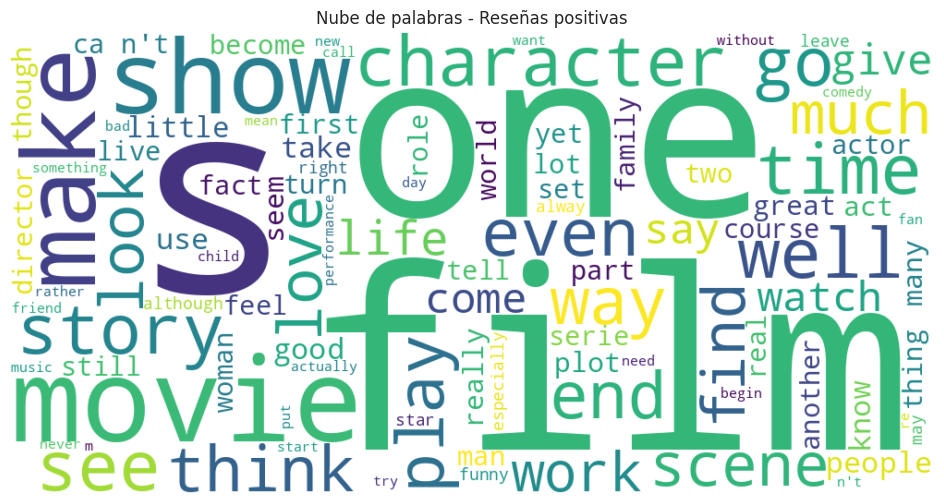

In [135]:
positive_text = " ".join(positive_reviews)

wordcloud_positive = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - Reseñas positivas")
plt.show()

**Palabras más frecuentes en reseñas negativas**

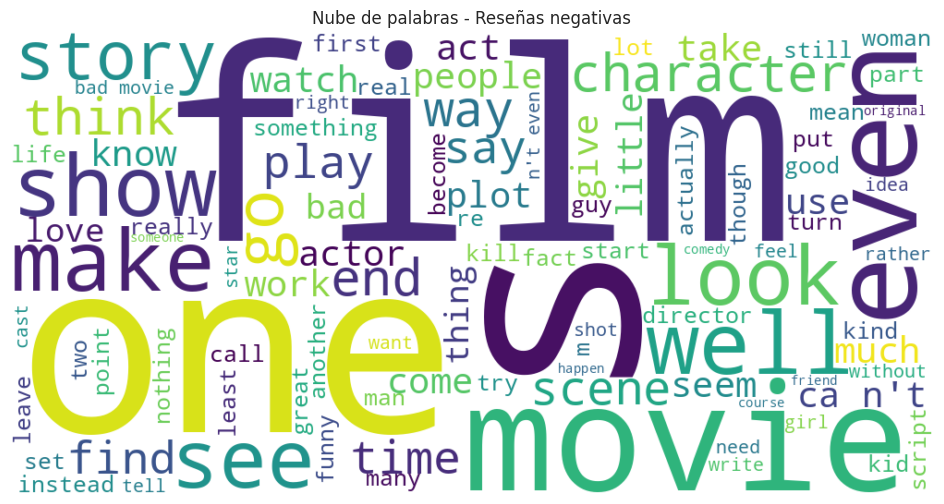

In [136]:
negative_text = " ".join(negative_reviews)

wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - Reseñas negativas")
plt.show()

**Interpretación**

Las nubes de palabras muestran que las reseñas positivas y negativas comparten muchos términos relacionados con las películas, como "film", "movie", "character" y "story".

En las reseñas positivas aparecen palabras como "good", "great" y "love", mientras que en las negativas se destacan términos como "bad" y "nothing".

Esto muestra que existen algunas diferencias entre ambos grupos, aunque muchas palabras aparecen en los dos. Por este motivo, será necesario utilizar modelos de clasificación que permitan analizar mejor el contenido de las reseñas y determinar su sentimiento.

# 10. Vectorización mediante TF-IDF

**Definición de las variables**

In [137]:
X = df_clean["clean_review"]
y = df_clean["sentiment"]

print("Cantidad de reseñas:", len(X))
print("Cantidad de etiquetas:", len(y))

Cantidad de reseñas: 50000
Cantidad de etiquetas: 50000


**División de los datos en entrenamiento y prueba**

In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Reseñas de entrenamiento: {len(X_train)}")
print(f"Reseñas de prueba: {len(X_test)}")

Reseñas de entrenamiento: 40000
Reseñas de prueba: 10000


**Verificación de la distribución**

In [139]:
print("Entrenamiento:")
print(y_train.value_counts(normalize=True).round(2))

print("\nPrueba:")
print(y_test.value_counts(normalize=True).round(2))

Entrenamiento:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

Prueba:
sentiment
negative    0.5
positive    0.5
Name: proportion, dtype: float64


**Aplicación de TF-IDF**

In [140]:
tfidf = TfidfVectorizer(
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(
    "Dimensiones de entrenamiento:",
    X_train_tfidf.shape
)

print(
    "Dimensiones de prueba:",
    X_test_tfidf.shape
)

Dimensiones de entrenamiento: (40000, 10000)
Dimensiones de prueba: (10000, 10000)


# 11. Modelos de Machine Learning

Una vez transformadas las reseñas en variables numéricas mediante TF-IDF, se procede al entrenamiento de modelos de clasificación supervisada.

Se utilizarán dos algoritmos: Regresión Logística y Naive Bayes.


**Regresión Logística**

In [141]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


**Evaluación de Regresión Logística**

In [142]:
y_pred_logistic = logistic_model.predict(
    X_test_tfidf
)


accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



**Matriz de confusión de Regresión Logística**

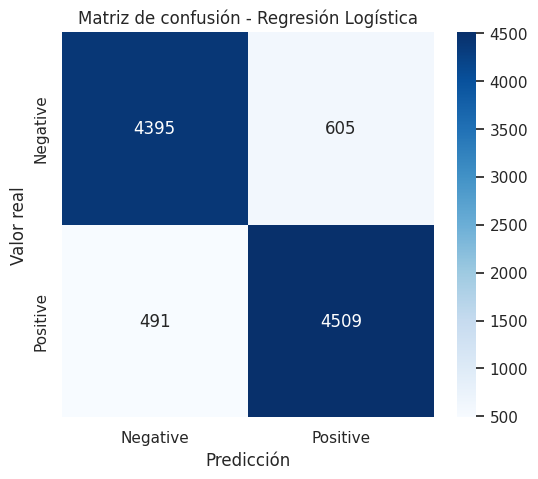

In [143]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

**Naive Bayes**

In [144]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


**Evaluación de Naive Bayes**

In [145]:
y_pred_nb = nb_model.predict(
    X_test_tfidf
)

accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)


print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      5000
    positive       0.85      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



**Matriz de confusión de Naive Bayes**

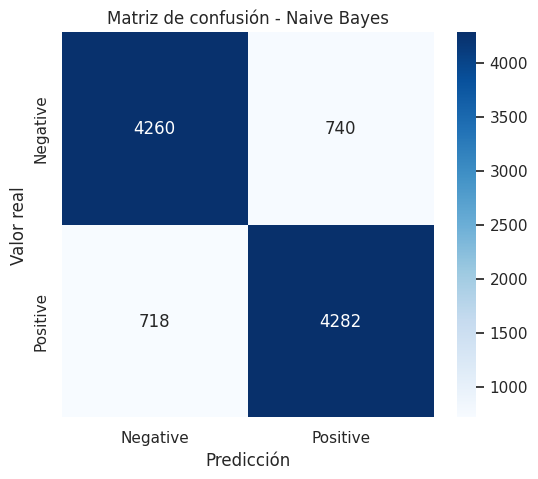

In [146]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Matriz de confusión - Naive Bayes")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

**Comparación de los modelos**

In [147]:
model_comparison = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_nb
    ]
})

model_comparison

,Modelo,Accuracy
0,Regresión Logística,0.8904
1,Naive Bayes,0.8542


Ambos modelos obtuvieron buenos resultados en la clasificación de las reseñas. Se observa que la Regresión Logística presentó el mejor rendimiento, logrando clasificar correctamente una mayor proporción de reseñas positivas y negativas.

# 12. Deep Learning - Red neuronal inicial

**Codificación de la variable objetivo**

In [148]:
y_train_nn = y_train.map({
    "negative": 0,
    "positive": 1
}).values

y_test_nn = y_test.map({
    "negative": 0,
    "positive": 1
}).values

print("Primeras etiquetas de entrenamiento:")
print(y_train_nn[:10])

Primeras etiquetas de entrenamiento:
[1 0 0 0 0 1 1 1 1 1]


**Preparación de las variables de entrada**

In [149]:
X_train_nn = X_train_tfidf.astype("float32").toarray()
X_test_nn = X_test_tfidf.astype("float32").toarray()

print("Dimensiones de entrenamiento:", X_train_nn.shape)
print("Dimensiones de prueba:", X_test_nn.shape)

Dimensiones de entrenamiento: (40000, 10000)
Dimensiones de prueba: (10000, 10000)


**Construcción de la red neuronal**

In [150]:
model_base = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(X_train_nn.shape[1],)
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_base.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,129 (2.44 MB)

 Trainable params: 640,129 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

**Entrenamiento**

In [151]:
model_base.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_base = model_base.fit(
    X_train_nn,
    y_train_nn,
    validation_split=0.20,
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8554 - loss: 0.4310 - val_accuracy: 0.8876 - val_loss: 0.2878
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9133 - loss: 0.2295 - val_accuracy: 0.8936 - val_loss: 0.2566
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9318 - loss: 0.1839 - val_accuracy: 0.8923 - val_loss: 0.2627
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9441 - loss: 0.1577 - val_accuracy: 0.8881 - val_loss: 0.2793
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9528 - loss: 0.1387 - val_accuracy: 0.8834 - val_loss: 0.3014


**Evolución del entrenamiento**

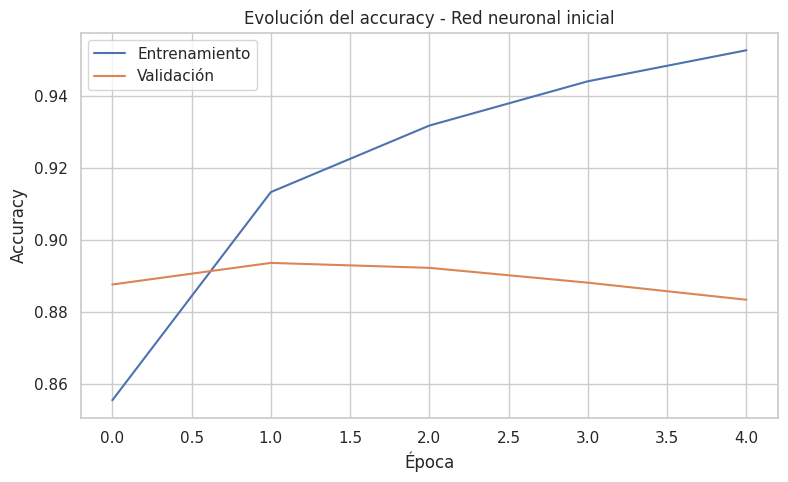

In [152]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_base.history["accuracy"],
    label="Entrenamiento"
)

plt.plot(
    history_base.history["val_accuracy"],
    label="Validación"
)

plt.title("Evolución del accuracy - Red neuronal inicial")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**Evolución de la pérdida**

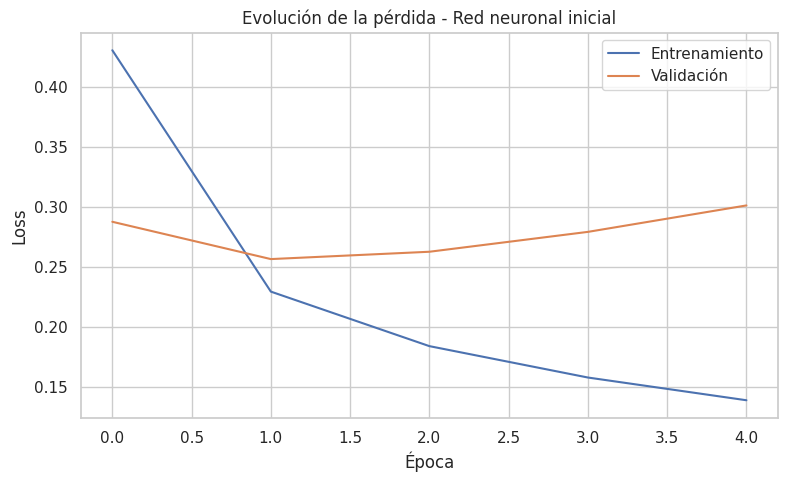

In [153]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_base.history["loss"],
    label="Entrenamiento"
)

plt.plot(
    history_base.history["val_loss"],
    label="Validación"
)

plt.title("Evolución de la pérdida - Red neuronal inicial")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.show()

**Evaluación de la red neuronal**

In [154]:
loss_base, accuracy_base = model_base.evaluate(
    X_test_nn,
    y_test_nn,
    verbose=0
)

print(f"Loss en test: {loss_base:.4f}")
print(f"Accuracy en test: {accuracy_base:.4f}")

Loss en test: 0.2966
Accuracy en test: 0.8861


**Conclusión**

La red neuronal inicial alcanzó un accuracy del 88,61% sobre el conjunto de prueba, mostrando un buen desempeño en la clasificación de sentimientos.

Sin embargo, las curvas de entrenamiento muestran señales de overfitting, ya que el rendimiento sobre los datos de entrenamiento continúa mejorando mientras que el rendimiento de validación comienza a disminuir.

Por este motivo, se buscará mejorar la arquitectura incorporando técnicas de regularización para obtener una mejor capacidad de generalización.

# 13. Mejora de la red neuronal

**Dropout**

Se incorpora Dropout como técnica para reducir el overfitting en las redes neuronales, la cual consiste en desactivar aleatoriamente un porcentaje de neuronas, evitando que el modelo dependa demasiado de determinadas conexiones.

In [155]:
model_improved = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(X_train_nn.shape[1],)
    ),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_improved.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,449 (4.92 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

**Early Stopping**

Se incorpora Early Stopping para controlar el comportamiento del modelo durante el entrenamiento. La misma detiene automáticamente el proceso cuando la pérdida de validación deja de mejorar, evitando continuar entrenando innecesariamente y reduciendo el riesgo de overfitting.

In [156]:
model_improved.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

**Entrenamiento de la red mejorada**

In [157]:
history_improved = model_improved.fit(
    X_train_nn,
    y_train_nn,
    validation_split=0.20,
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.8457 - loss: 0.3747 - val_accuracy: 0.8907 - val_loss: 0.2617
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9216 - loss: 0.2039 - val_accuracy: 0.8870 - val_loss: 0.2722
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9477 - loss: 0.1470 - val_accuracy: 0.8823 - val_loss: 0.3087


**Evolución del entrenamiento**

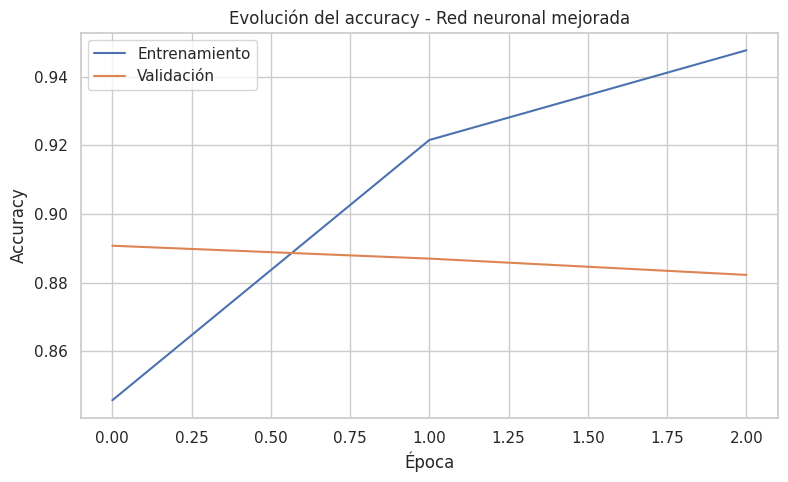

In [158]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_improved.history["accuracy"],
    label="Entrenamiento"
)

plt.plot(
    history_improved.history["val_accuracy"],
    label="Validación"
)

plt.title("Evolución del accuracy - Red neuronal mejorada")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**Evaluación de la pérdida**

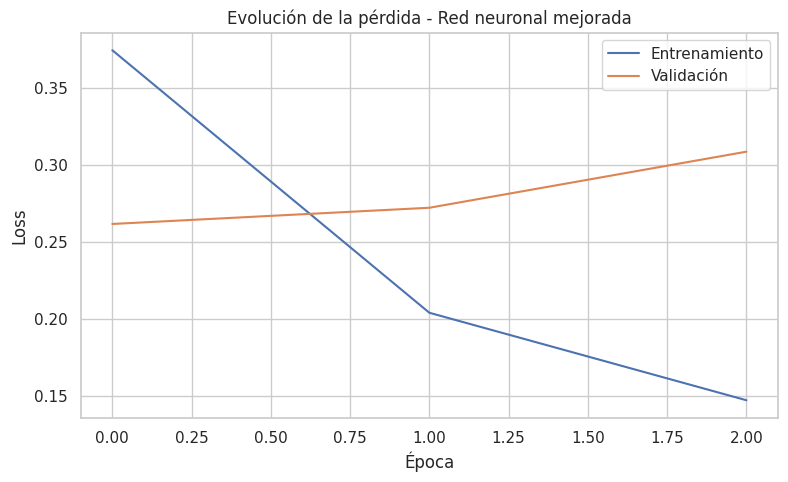

In [159]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_improved.history["loss"],
    label="Entrenamiento"
)

plt.plot(
    history_improved.history["val_loss"],
    label="Validación"
)

plt.title("Evolución de la pérdida - Red neuronal mejorada")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.show()

**Evaluación final**

In [160]:
loss_improved, accuracy_improved = model_improved.evaluate(
    X_test_nn,
    y_test_nn,
    verbose=0
)

print(f"Loss en test: {loss_improved:.4f}")
print(f"Accuracy en test: {accuracy_improved:.4f}")

Loss en test: 0.2605
Accuracy en test: 0.8938


**Conclusión**

La red neuronal mejorada alcanzó un accuracy del 89,38%, superando el 88,61% obtenido por la red inicial.

La incorporación de Dropout y Early Stopping permitió controlar parcialmente el overfitting, aunque las curvas muestran que el modelo todavía comienza a perder capacidad de generalización después de las primeras épocas.

En comparación con los modelos anteriores, la red mejorada obtuvo el mejor resultado, aunque la diferencia con la Regresión Logística fue pequeña.

# 14. Comparación final de modelos

In [161]:
final_comparison = pd.DataFrame({
    "Modelo": [
        "Naive Bayes",
        "Regresión Logística",
        "Red neuronal inicial",
        "Red neuronal mejorada"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_logistic,
        accuracy_base,
        accuracy_improved
    ]
})

final_comparison = final_comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

final_comparison

,Modelo,Accuracy
0,Red neuronal mejorada,0.8938
1,Regresión Logística,0.8904
2,Red neuronal inicial,0.8861
3,Naive Bayes,0.8542


Todos los modelos lograron un buen rendimiento en la clasificación de sentimientos, siendo la red neuronal mejorada la de mejor desempeño. Sin embargo, la pequeña diferencia respecto de la Regresión Logística demuestra que un modelo más complejo no siempre produce una mejora considerable.

# 15. Prueba del modelo con nuevas reseñas

**Función de predicción**

In [162]:
def predict_sentiment(review):

    clean_text = preprocess_text(review)

    vectorized_text = tfidf.transform([clean_text])
    vectorized_text = vectorized_text.astype("float32").toarray()

    probability = model_improved.predict(
        vectorized_text,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        sentiment = "Positiva"
        confidence = probability
    else:
        sentiment = "Negativa"
        confidence = 1 - probability

    return sentiment, confidence

**Prueba de reseña positiva**

In [163]:
positive_example = """
I really loved this movie. The story was interesting,
the acting was excellent and the characters were amazing.
"""

sentiment, confidence = predict_sentiment(
    positive_example
)

print("Reseña:")
print(positive_example)

print("Predicción:", sentiment)
print(f"Confianza: {confidence:.2%}")

Reseña:

I really loved this movie. The story was interesting,
the acting was excellent and the characters were amazing.

Predicción: Positiva
Confianza: 98.43%


**Prueba de reseña negativa**

In [164]:
negative_example = """
This movie was terrible. The story was boring,
the acting was bad and I did not enjoy it.
"""

sentiment, confidence = predict_sentiment(
    negative_example
)

print("Reseña:")
print(negative_example)

print("Predicción:", sentiment)
print(f"Confianza: {confidence:.2%}")

Reseña:

This movie was terrible. The story was boring,
the acting was bad and I did not enjoy it.

Predicción: Negativa
Confianza: 99.56%


# 16. Conclusiones finales

El proyecto permitió desarrollar un análisis de sentimiento sobre reseñas de películas utilizando técnicas de NLP, Machine Learning y Deep Learning.

En primer lugar, se realizó la exploración y el preprocesamiento de las reseñas mediante técnicas como limpieza del texto, tokenización, eliminación de stopwords y lematización. Las nubes de palabras permitieron observar que las reseñas positivas y negativas comparten muchos términos relacionados con las películas, aunque también presentan algunas diferencias en el vocabulario utilizado.

Posteriormente, las reseñas fueron transformadas mediante TF-IDF para poder entrenar diferentes modelos de clasificación. Los resultados obtenidos fueron:

- Naive Bayes: 85,42%
- Regresión Logística: 89,04%
- Red neuronal inicial: 88,61%
- Red neuronal mejorada: 89,38%

La red neuronal mejorada obtuvo el mejor resultado, aunque la diferencia respecto de la Regresión Logística fue pequeña. Además, la incorporación de Dropout y Early Stopping permitió mejorar el resultado de la primera red neuronal y controlar parcialmente el overfitting detectado durante el entrenamiento.

Los resultados permiten respaldar las principales hipótesis planteadas al comienzo del proyecto. Se encontraron algunas diferencias entre el vocabulario de las reseñas positivas y negativas, y se comprobó que es posible predecir el sentimiento de una reseña utilizando únicamente su contenido textual. También se observó una mejora al modificar la arquitectura de la red neuronal inicial.

A pesar de los buenos resultados, el proyecto presenta algunas limitaciones. Las nubes de palabras permiten analizar la frecuencia de los términos, pero no interpretan completamente el contexto en el que aparecen. Además, los modelos utilizados pueden tener dificultades frente a expresiones más complejas, como ironías o frases cuyo significado depende fuertemente del contexto.

Como posibles mejoras futuras, se podrían probar diferentes configuraciones de TF-IDF, realizar un ajuste más amplio de los hiperparámetros y utilizar técnicas de NLP y arquitecturas de Deep Learning más avanzadas.

En conclusión, el proyecto demuestra que la combinación de técnicas de NLP con modelos de Machine Learning y Deep Learning permite obtener buenos resultados en la clasificación automática de sentimientos, alcanzando un 89,38% de accuracy con el mejor modelo desarrollado.